In [305]:
import sys
sys.path.append('..')
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate  # TwoLocal, ZZFeatureMap, etc
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt

 ## Try Unitary AQC 

### Try MPF for the trotter evolution (?)

### Try differently

In [500]:
service = QiskitRuntimeService(instance='client-enablement/solutions/demo-testing')
backend = service.backend("ibm_torino")

qubit_subset = [4, 5, 6, 7, 8, 16, 17, 23, 24, 25, 26, 27] # trying 1 loop for torino
remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
rev_map = {val:key for key,val in remap.items()}

cm= backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a,b) if a<b else (b,a) for a,b in list(reduced_map.get_edges())}
ent_dec = [(rev_map[i], rev_map[j]) for i,j in edge_list]

def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()
H = Heisenberg(1, 12, edge_list)


def prep_psi_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9)
    qc.cx(9,10)
    qc.cx(10,11)
    qc.cx(9,8)
    qc.cx(11,6)
    qc.cx(8,7)
    qc.cx(7,5)
    qc.cx(6,4)
    qc.cx(4,3)
    qc.cx(5,0)
    qc.cx(3,2)
    #make checkpoints
    qc.cx(11, 17)
    qc.cx(4, 16)
    qc.cx(2, 15)
    qc.cx(0, 14)
    qc.cx(7, 13)
    #undo entanglement on undesired qubits
    qc.cx(2,3)
    qc.cx(4,6)
    qc.cx(11,10)
    qc.cx(9,8)
    qc.cx(7,5)
    return qc

def prep_psi_0_by_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9, ctrl_state='0')
    qc.cx(17, 11, ctrl_state='0')
    qc.cx(16,4, ctrl_state='0')
    qc.cx(15,2, ctrl_state='0')
    qc.cx(14,0, ctrl_state='0')
    qc.cx(13,7, ctrl_state='0')
    return qc



In [510]:
from qiskit.transpiler import generate_preset_pass_manager 

t_steps = 6
circuits = np.ndarray([t_steps,t_steps], dtype= QuantumCircuit)
H_tilde = np.zeros([t_steps,t_steps], dtype=complex)
S_tilde = np.zeros([t_steps,t_steps], dtype=complex)
delta_t = np.pi/40

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2*delta_t,0,1)
Rxyz_circ.ryy(2*delta_t,0,1)
Rxyz_circ.rzz(2*delta_t,0,1)
Rxyz_instr = Rxyz_circ.to_instruction(label='RXX+YY+ZZ')
qc_temp = QuantumCircuit(12)
for edge in edge_list:
    qc_temp.append(Rxyz_instr,edge)
time_evol = QuantumCircuit(12).compose(qc_temp)

real_obs_H = SparsePauliOp('XXXXXX', 1) ^ H 
imag_obs_H = SparsePauliOp('YXXXXX', 1) ^ H
real_obs_S = SparsePauliOp('XXXXXX', 1) ^ SparsePauliOp('I'*12, 1)
imag_obs_S = SparsePauliOp('YXXXXX', 1) ^ SparsePauliOp('I'*12, 1)



for j in range(t_steps):
    for i in range(j+1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]



In [511]:
f'Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}'

'Max circuit depth:43'

In [512]:
f'Max number of 2q gates= {max([circs[i][j].num_nonlocal_gates() for i in range(t_steps) for j in range(t_steps)])}'

'Max number of 2q gates= 207'

### Circuit execution

In [513]:
#basis state has energy -12
from qiskit_ibm_runtime import EstimatorV2, Batch, EstimatorOptions
pub1=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[0:2] for circ in circ_list]
pub2=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[2:4] for circ in circ_list]


with Batch(backend=backend) as batch:
    estimator = EstimatorV2(mode=batch)
    estimator.options.default_shots = 50000
    estimator.options.resilience_level = 2
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = 'XY4'
    est_job_1 = estimator.run(pub1)
    est_job_2 = estimator.run(pub2)


   

In [ ]:
pub3=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[4:6] for circ in circ_list]
estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = 50000
estimator.options.resilience_level = 2
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = 'XY4'
est_job_3 = estimator.run(pub3)

In [522]:
est_job_1_results = service.job(est_job_1.job_id()).result()

est_job_2_results = service.job(est_job_2.job_id()).result()

est_job_3_results = service.job(est_job_3.job_id()).result()

In [523]:
idx=0
for i in range(2):
    for j in range(t_steps):
            H_tilde[i,j] = est_job_1_results[idx].data.evs[0] + 1j * est_job_1_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_1_results[idx].data.evs[2] + 1j * est_job_1_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(2,4):
    for j in range(t_steps):
            H_tilde[i,j] = est_job_2_results[idx].data.evs[0] + 1j * est_job_2_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_2_results[idx].data.evs[2] + 1j * est_job_2_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(4,6):
    for j in range(t_steps):
            H_tilde[i,j] = est_job_3_results[idx].data.evs[0] + 1j * est_job_3_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_3_results[idx].data.evs[2] + 1j * est_job_3_results[idx].data.evs[3]
            idx+=1

In [524]:
S_tilde

array([[ 8.09492785e-01-2.42150869e-03j, -2.19175165e-02+8.12636869e-01j,
        -3.46701459e-01-8.85678260e-02j,  3.26823247e-02-1.00914190e-02j,
        -9.96069374e-03+1.55882512e-04j,  3.39335671e-18+2.45647674e-02j],
       [ 1.86938664e-03+7.50426306e-01j,  9.10367481e-01-5.79825977e-03j,
        -8.73916479e-02+7.58182841e-01j, -9.08951722e-02-1.85468751e-01j,
         7.35986226e-02-4.02121872e-03j,  5.18982821e-02+3.28460426e-03j],
       [-2.50156641e-01-3.15739230e-02j, -6.31628620e-02+5.13944249e-01j,
         7.15774446e-01-3.79614077e-02j, -5.57750459e-04+4.66995879e-01j,
        -2.33432322e-01-5.41561740e-02j,  1.01860850e-02+2.84865602e-03j],
       [ 3.84188016e-02-4.03471773e-02j, -1.19290078e-01-3.57174178e-02j,
        -3.98762243e-02+3.71256972e-01j,  6.46099238e-01-2.32053228e-02j,
        -2.11737292e-02+4.97173269e-01j, -2.96402315e-02+1.09422526e-02j],
       [ 9.04520138e-03-2.71415104e-03j,  1.36938505e-02-8.10925382e-04j,
         5.48696467e-04-1.18846706

In [525]:
H_tilde

array([[-8.99361897e+00+1.33363680e-01j,  4.13720792e+00-8.71809879e+00j,
         2.57941302e+00+3.34839459e+00j, -1.40556362e+00-4.14007709e-01j,
         1.50878667e-01-1.83375987e-02j, -3.13498582e-02+8.25919750e-02j],
       [ 3.98019090e+00-8.94599804e+00j, -1.02060791e+01-1.58044017e-01j,
         2.42451615e+00-6.07965868e+00j,  1.59378390e+00+2.52855093e+00j,
        -8.96320457e-01-6.47196637e-02j, -3.78091392e-02-4.50777773e-02j],
       [ 1.94090594e+00+2.83937506e+00j,  1.49758516e+00-5.54214831e+00j,
        -8.36568546e+00+2.17859246e-02j,  1.48834865e+00-3.38373148e+00j,
         6.13754672e-01+1.74509137e+00j, -4.02066881e-02-7.75636516e-02j],
       [-1.22126630e+00+2.95057324e-03j,  1.04889097e+00+2.09006231e+00j,
         1.18438281e+00-3.69312914e+00j, -6.97743148e+00-3.68617719e-02j,
         1.11439875e+00-2.84626697e+00j,  8.73298240e-02-6.17149435e-03j],
       [ 1.26161400e-01+1.32923326e-01j,  1.13309839e-01-2.97971712e-01j,
        -1.17463827e+00+1.62383270

1
2
3
4
5
GSE`s: [np.complex128(-11.110583810622481+0.13151359305542576j), np.complex128(-13.726231141990342-2.248616911115427j), np.complex128(-13.832280728333878-2.578338964153085j), np.complex128(-13.706877051325495-3.2609039862614653j), np.complex128(-13.593707626167044-2.5761765009073585j)]


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

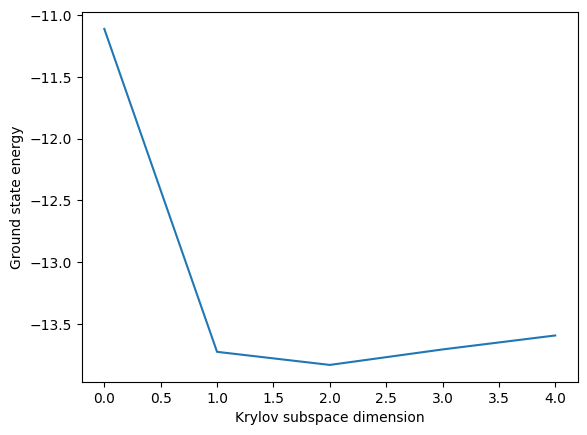

In [526]:
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-8)
print(f'GSE`s: {GSEs}')
plt.plot(GSEs) # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel('Krylov subspace dimension')
plt.ylabel('Ground state energy')

# Run on simulator for comparison

In [527]:
from qiskit.transpiler import generate_preset_pass_manager 
from qiskit.primitives import StatevectorEstimator

t_steps = 6
circuits = np.ndarray([t_steps,t_steps], dtype= QuantumCircuit)
H_tilde = np.zeros([t_steps,t_steps], dtype=complex)
S_tilde = np.zeros([t_steps,t_steps], dtype=complex)
delta_t = np.pi/40

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2*delta_t,0,1)
Rxyz_circ.ryy(2*delta_t,0,1)
Rxyz_circ.rzz(2*delta_t,0,1)
Rxyz_instr = Rxyz_circ.to_instruction(label='RXX+YY+ZZ')
qc_temp = QuantumCircuit(12)
for edge in edge_list:
    qc_temp.append(Rxyz_instr,edge)
time_evol = QuantumCircuit(12).compose(qc_temp)

real_obs_H = SparsePauliOp('XXXXXX', 1) ^ H 
imag_obs_H = SparsePauliOp('YXXXXX', 1) ^ H
real_obs_S = SparsePauliOp('XXXXXX', 1) ^ SparsePauliOp('I'*12, 1)
imag_obs_S = SparsePauliOp('YXXXXX', 1) ^ SparsePauliOp('I'*12, 1)



for j in range(t_steps):
    for i in range(j+1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])


sv=StatevectorEstimator()
sv_job=sv.run([(circs[i][j], [real_obs_H, imag_obs_H,real_obs_S, imag_obs_S]) for i in range(t_steps) for j in range(t_steps)])

sv_res = sv_job.result()

In [528]:
idx=0
for i in range(t_steps):
    for j in range(t_steps):
            H_tilde[i,j] = sv_res[idx].data.evs[0] + 1j * sv_res[idx].data.evs[1]
            S_tilde[i,j] = sv_res[idx].data.evs[2] + 1j * sv_res[idx].data.evs[3]
            idx+=1
print(H_tilde)

print(S_tilde)

[[-12.        +0.00000000e+00j   6.44605962-9.32576050e+00j
    3.23814767+8.53998277e+00j  -5.5527575 -2.01013286e+00j
    3.26664402-6.58908899e-01j  -2.13163511+9.21184713e-01j]
 [  6.44605962-9.32576050e+00j -11.96300088-2.15108107e-16j
    6.43232415-9.26373005e+00j   3.18151687+8.50887092e+00j
   -5.51510005-2.03663014e+00j   3.26174169-6.32596679e-01j]
 [  3.23814767+8.53998277e+00j   6.43232415-9.26373005e+00j
  -11.86784426+5.10306489e-16j   6.40985317-9.16623135e+00j
    3.1152289 +8.46995837e+00j  -5.47741645-2.05908768e+00j]
 [ -5.5527575 -2.01013286e+00j   3.18151687+8.50887092e+00j
    6.40985317-9.16623135e+00j -11.75405599+1.45236677e-17j
    6.38646212-9.07288238e+00j   3.0659177 +8.43650061e+00j]
 [  3.26664402-6.58908899e-01j  -5.51510005-2.03663014e+00j
    3.1152289 +8.46995837e+00j   6.38646212-9.07288238e+00j
  -11.66494291+5.91264003e-16j   6.36931779-9.01644754e+00j]
 [ -2.13163511+9.21184713e-01j   3.26174169-6.32596679e-01j
   -5.47741645-2.05908768e+00j   3.

1
2
3
4
5


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

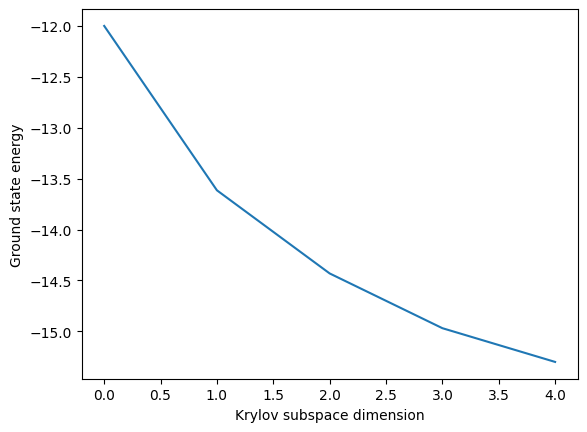

In [529]:
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-8)
plt.plot(GSEs) # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel('Krylov subspace dimension')
plt.ylabel('Ground state energy')